# Notebook 02 — QR Calibration Clean

**Pipeline:** Adaptive Classical Vision Pipeline for Cut-Edge Detection  
**Step 2:** QR candidate detection → corner-based QR selection → affine metric rectification

This clean version is based on what we observed in the previous notebook:

- CLAHE is not used in the main preprocessing because it amplifies rubber texture.
- The raw QR candidate detector already finds the real QRs.
- The main failure was the final selection: false candidates sometimes obtained higher scores than real QRs.
- Instead of selecting the best 3 candidates only by score, this notebook assigns candidates to the nearest image/table corner and keeps the best one per corner.

**Input:** `outputs/01_preprocessed/`  
**Output:** `outputs/02_rectified_clean/` by default.

## 1. Imports and configuration

In [1]:
!pip install opencv-python numpy matplotlib

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────
PREPROCESSED_DIR = Path("outputs/01_preprocessed")

# Use this clean output folder while testing.
# When validated, either change this to "outputs/02_rectified"
# or update the next notebooks to read from this folder.
OUTPUT_DIR = Path("outputs/02_rectified_clean")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEBUG_DIR = OUTPUT_DIR / "debug"
ALL_CANDIDATES_DIR = DEBUG_DIR / "all_candidates"
FINAL_QRS_DIR = DEBUG_DIR / "final_qrs"
CROPS_ALL_DIR = DEBUG_DIR / "crops_all_candidates"
CROPS_FINAL_DIR = DEBUG_DIR / "crops_final_qrs"

for d in [ALL_CANDIDATES_DIR, FINAL_QRS_DIR, CROPS_ALL_DIR, CROPS_FINAL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Physical reference ─────────────────────────────────────────────────────
# QR reference points define an 800 mm x 800 mm metric square.
QR_LEG_MM = 800.0

# Output rectified image: 800x800 px, so 1 px = 1 mm.
RECTIFIED_SIZE = int(QR_LEG_MM)

# ── Raw QR candidate detection parameters ──────────────────────────────────
# These are intentionally permissive because the raw detector already finds
# the true QRs. Final selection is handled later by corner assignment.
MIN_SIZE_RATIO = 0.006
MAX_SIZE_RATIO = 0.080
MIN_WHITE_RING = 0.45
MIN_EDGE_DENSITY = 0.08

# ── Final QR selection parameters ──────────────────────────────────────────
# A real QR should be close to one of the image/table corners.
# Candidates farther than this from every corner are ignored in final selection.
MAX_CORNER_DISTANCE_RATIO = 0.30

# If more than 3 image corners have candidates, keep the 3 best by final score.
EXPECTED_QRS = 3

# ── Image filtering ────────────────────────────────────────────────────────
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png"}
DATASET_PREFIX = "Multimedia_"

print(f"Preprocessed dir : {PREPROCESSED_DIR.resolve()}")
print(f"Output dir       : {OUTPUT_DIR.resolve()}")
print(f"Debug dir        : {DEBUG_DIR.resolve()}")

Preprocessed dir : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\01_preprocessed
Output dir       : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\02_rectified_clean
Debug dir        : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\02_rectified_clean\debug


## 2. Raw QR candidate detection

This part is kept close to the previous version because it was already detecting the real QRs.
The detector is visual: it looks for small square regions with internal edge density and a white surrounding area.

In [4]:
def _merge_close_candidates(candidates, dist_factor=1.5):
    """
    Merge duplicated candidates that correspond to the same QR region.
    Keeps the highest-scoring candidate in each local area.
    """
    merged = []

    for c in sorted(candidates, key=lambda z: z.get("score", 0), reverse=True):
        cx, cy = c["center"]
        duplicated = False

        for m in merged:
            mx, my = m["center"]
            max_dist = dist_factor * max(c.get("size", 20), m.get("size", 20))

            if np.hypot(cx - mx, cy - my) < max_dist:
                duplicated = True
                break

        if not duplicated:
            merged.append(c)

    return merged


def detect_qr_candidates(img_gray: np.ndarray) -> list:
    """
    Detect QR candidates from the preprocessed grayscale image.

    Important:
    - This function is permissive.
    - It may detect false positives.
    - Final selection is handled by corner-based filtering afterwards.
    """
    H, W = img_gray.shape
    diag = np.hypot(H, W)

    min_size = int(diag * MIN_SIZE_RATIO)
    max_size = int(diag * MAX_SIZE_RATIO)

    binaries = [
        cv2.adaptiveThreshold(
            img_gray, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV,
            21, 5
        ),
        cv2.adaptiveThreshold(
            img_gray, 255,
            cv2.ADAPTIVE_THRESH_MEAN_C,
            cv2.THRESH_BINARY_INV,
            21, 7
        ),
        cv2.threshold(
            img_gray, 0, 255,
            cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
        )[1]
    ]

    candidates = []

    for binary in binaries:
        cnts, _ = cv2.findContours(
            binary,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        for cnt in cnts:
            x, y, w, h = cv2.boundingRect(cnt)
            size = max(w, h)

            if size < min_size or size > max_size:
                continue

            aspect = w / (h + 1e-6)
            if not (0.55 <= aspect <= 1.8):
                continue

            fill_ratio = cv2.contourArea(cnt) / (w * h + 1e-6)
            if fill_ratio < 0.05:
                continue

            # White surrounding region check.
            pad = int(size * 1.4)
            x1 = max(0, x - pad)
            y1 = max(0, y - pad)
            x2 = min(W, x + w + pad)
            y2 = min(H, y + h + pad)

            ring = img_gray[y1:y2, x1:x2].copy()

            inner_x1 = max(0, x - x1)
            inner_y1 = max(0, y - y1)
            inner_x2 = min(ring.shape[1], x + w - x1)
            inner_y2 = min(ring.shape[0], y + h - y1)

            ring[inner_y1:inner_y2, inner_x1:inner_x2] = 0
            vals = ring[ring > 0]

            white_ring = np.mean(vals > 135) if vals.size else 0
            if white_ring < MIN_WHITE_RING:
                continue

            # Internal edge density check.
            roi = img_gray[y:y+h, x:x+w]
            edge_density = np.mean(cv2.Canny(roi, 40, 120) > 0)

            if edge_density < MIN_EDGE_DENSITY:
                continue

            score = white_ring + edge_density - abs(aspect - 1.0) * 0.5

            candidates.append({
                "center": (float(x + w / 2), float(y + h / 2)),
                "size": float(size),
                "bbox": (int(x), int(y), int(w), int(h)),
                "score": float(score),
                "white_ring": float(white_ring),
                "edge_density": float(edge_density),
                "aspect": float(aspect),
            })

    candidates = sorted(candidates, key=lambda c: c.get("score", 0), reverse=True)
    return _merge_close_candidates(candidates)

## 3. Corner-based final QR selection

Instead of selecting the top 3 candidates by score, each candidate is assigned to its nearest image corner:

- `TL`: top-left
- `TR`: top-right
- `BL`: bottom-left
- `BR`: bottom-right

Candidates too far from every corner are ignored. Then the best candidate per corner is selected.

In [5]:
METRIC_POINTS = {
    "TL": np.array([0.0, 0.0], dtype=np.float32),
    "TR": np.array([QR_LEG_MM, 0.0], dtype=np.float32),
    "BL": np.array([0.0, QR_LEG_MM], dtype=np.float32),
    "BR": np.array([QR_LEG_MM, QR_LEG_MM], dtype=np.float32),
}


def get_image_corner_points(img_shape: tuple) -> dict:
    """
    Return image corner coordinates for the current image.
    """
    img_h, img_w = img_shape[:2]

    return {
        "TL": np.array([0.0, 0.0], dtype=np.float32),
        "TR": np.array([img_w - 1.0, 0.0], dtype=np.float32),
        "BL": np.array([0.0, img_h - 1.0], dtype=np.float32),
        "BR": np.array([img_w - 1.0, img_h - 1.0], dtype=np.float32),
    }


def candidate_center(candidate: dict) -> np.ndarray:
    """
    Return center point of candidate bbox.
    """
    x, y, w, h = candidate["bbox"]
    return np.array([x + w / 2.0, y + h / 2.0], dtype=np.float32)


def assign_candidates_to_corners(img_shape: tuple, candidates: list) -> list:
    """
    Assign each candidate to the nearest image corner.

    Candidates too far from any corner are still kept for debugging,
    but they are marked as OUT and ignored during final QR selection.
    """
    img_h, img_w = img_shape[:2]
    diag = np.hypot(img_h, img_w)
    max_corner_dist = MAX_CORNER_DISTANCE_RATIO * diag

    corners = get_image_corner_points(img_shape)

    assigned = []

    for cand in candidates:
        cand = cand.copy()
        center = candidate_center(cand)

        distances = {
            label: float(np.linalg.norm(center - corner_pt))
            for label, corner_pt in corners.items()
        }

        nearest_label = min(distances, key=distances.get)
        nearest_dist = distances[nearest_label]

        corner_score = 1.0 - min(nearest_dist / max_corner_dist, 1.0)

        if nearest_dist <= max_corner_dist:
            cand["corner_label"] = nearest_label
        else:
            cand["corner_label"] = "OUT"

        cand["corner_distance_px"] = float(nearest_dist)
        cand["corner_score"] = float(corner_score)

        # Final score is still simple:
        # candidate visual score, slightly reinforced by corner proximity.
        cand["final_score"] = float(cand.get("score", 0.0) * (1.0 + 0.5 * corner_score))

        assigned.append(cand)

    assigned = sorted(assigned, key=lambda c: c.get("final_score", 0), reverse=True)

    return assigned


def select_final_qrs_by_corner(assigned_candidates: list, expected_qrs: int = EXPECTED_QRS) -> dict:
    """
    Select the best candidate for each image corner.
    If more than expected_qrs corners are selected, keep the best expected_qrs candidates.
    """
    best_by_corner = {}

    for cand in assigned_candidates:
        label = cand.get("corner_label", "OUT")

        if label == "OUT":
            continue

        if label not in best_by_corner:
            best_by_corner[label] = cand
            continue

        if cand.get("final_score", 0) > best_by_corner[label].get("final_score", 0):
            best_by_corner[label] = cand

    selected_items = sorted(
        best_by_corner.items(),
        key=lambda item: item[1].get("final_score", 0),
        reverse=True
    )

    if len(selected_items) > expected_qrs:
        selected_items = selected_items[:expected_qrs]

    # Return ordered by a stable label order for readability.
    selected = dict(selected_items)
    label_order = ["TL", "TR", "BL", "BR"]

    return {
        label: selected[label]
        for label in label_order
        if label in selected
    }

## 4. Reference point extraction and affine metric rectification

Each selected QR uses the exterior point that corresponds to its image/table corner:

- `TL` → `(x, y)`
- `TR` → `(x+w, y)`
- `BL` → `(x, y+h)`
- `BR` → `(x+w, y+h)`

These points are mapped to the metric square:

- `TL` → `(0, 0)`
- `TR` → `(800, 0)`
- `BL` → `(0, 800)`
- `BR` → `(800, 800)`

In [6]:
def get_exterior_reference_point(label: str, candidate: dict) -> np.ndarray:
    """
    Return the exterior table-aligned point of a QR candidate.
    """
    x, y, w, h = candidate["bbox"]

    if label == "TL":
        return np.array([x, y], dtype=np.float32)

    if label == "TR":
        return np.array([x + w, y], dtype=np.float32)

    if label == "BL":
        return np.array([x, y + h], dtype=np.float32)

    if label == "BR":
        return np.array([x + w, y + h], dtype=np.float32)

    raise ValueError(f"Unknown QR label: {label}")


def build_correspondences(selected_qrs: dict) -> tuple[np.ndarray, np.ndarray, list]:
    """
    Build source and destination point arrays for affine transform.
    """
    labels = list(selected_qrs.keys())

    if len(labels) != 3:
        raise ValueError(f"Affine transform requires exactly 3 QRs, got {len(labels)}")

    src_points = []
    dst_points = []

    for label in labels:
        src_points.append(get_exterior_reference_point(label, selected_qrs[label]))
        dst_points.append(METRIC_POINTS[label])

    src_points = np.array(src_points, dtype=np.float32)
    dst_points = np.array(dst_points, dtype=np.float32)

    return src_points, dst_points, labels


def estimate_original_px_per_mm(src_points: np.ndarray, dst_points: np.ndarray) -> float:
    """
    Estimate original px/mm from all available point pairs.
    This is only diagnostic. The rectified output uses 1 px = 1 mm.
    """
    ratios = []

    for i in range(len(src_points)):
        for j in range(i + 1, len(src_points)):
            px_dist = np.linalg.norm(src_points[i] - src_points[j])
            mm_dist = np.linalg.norm(dst_points[i] - dst_points[j])

            if mm_dist > 1e-6:
                ratios.append(px_dist / mm_dist)

    if not ratios:
        return float("nan")

    return float(np.mean(ratios))


def compute_affine_metric_transform(src_points: np.ndarray, dst_points: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute affine transform from image pixel coordinates to metric coordinates.

    Returns:
      - A: 2x3 affine matrix
      - H: 3x3 homogeneous matrix
    """
    A = cv2.getAffineTransform(src_points, dst_points)
    H = np.vstack([A, [0, 0, 1]]).astype(np.float32)

    return A.astype(np.float32), H


def rectify_image_to_metric(img: np.ndarray, A: np.ndarray) -> np.ndarray:
    """
    Rectify image into an 800x800 metric image.
    After this transformation, 1 pixel corresponds to approximately 1 mm.
    """
    return cv2.warpAffine(
        img,
        A,
        (RECTIFIED_SIZE, RECTIFIED_SIZE),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

## 5. Debug visualization utilities

In [7]:
def _to_bgr(img_gray: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)


def _safe_crop(img: np.ndarray, bbox: tuple, pad: int = 8) -> np.ndarray:
    x, y, w, h = bbox
    H, W = img.shape[:2]

    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(W, x + w + pad)
    y2 = min(H, y + h + pad)

    return img[y1:y2, x1:x2]


def save_all_candidates_debug(image_name: str, img_gray: np.ndarray, candidates: list):
    """
    Save image with all candidates.
    Candidates assigned to a corner display their corner label.
    Candidates too far from the corners display OUT.
    """
    debug_img = _to_bgr(img_gray)
    stem = Path(image_name).stem

    for idx, cand in enumerate(candidates):
        x, y, w, h = cand["bbox"]
        raw_score = cand.get("score", 0.0)
        final_score = cand.get("final_score", raw_score)
        label = cand.get("corner_label", "?")
        corner_score = cand.get("corner_score", 0.0)

        color = (255, 0, 0) if label != "OUT" else (100, 100, 100)

        cv2.rectangle(debug_img, (x, y), (x + w, y + h), color, 2)

        text = f"{idx} | {label} | r:{raw_score:.2f} f:{final_score:.2f} c:{corner_score:.2f}"
        cv2.putText(
            debug_img,
            text,
            (x, max(15, y - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.42,
            color,
            1,
            cv2.LINE_AA
        )

        crop = _safe_crop(img_gray, cand["bbox"])
        crop_path = CROPS_ALL_DIR / f"{stem}_candidate_{idx:02d}_{label}_score_{final_score:.2f}.png"
        cv2.imwrite(str(crop_path), crop)

    out_path = ALL_CANDIDATES_DIR / f"{stem}_all_candidates.png"
    cv2.imwrite(str(out_path), debug_img)


def save_final_qrs_debug(
    image_name: str,
    img_gray: np.ndarray,
    selected_qrs: dict,
    src_points: np.ndarray,
):
    """
    Save image with only the final selected QRs.
    """
    debug_img = _to_bgr(img_gray)
    stem = Path(image_name).stem

    colors = {
        "TL": (0, 255, 0),
        "TR": (255, 255, 0),
        "BL": (255, 0, 255),
        "BR": (0, 165, 255),
    }

    labels = list(selected_qrs.keys())

    for label in labels:
        cand = selected_qrs[label]
        x, y, w, h = cand["bbox"]
        score = cand.get("final_score", cand.get("score", 0.0))
        color = colors[label]

        cv2.rectangle(debug_img, (x, y), (x + w, y + h), color, 3)

        text = f"{label} | {score:.2f}"
        cv2.putText(
            debug_img,
            text,
            (x, max(20, y - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.60,
            color,
            2,
            cv2.LINE_AA
        )

        crop = _safe_crop(img_gray, cand["bbox"])
        crop_path = CROPS_FINAL_DIR / f"{stem}_{label}_score_{score:.2f}.png"
        cv2.imwrite(str(crop_path), crop)

    for cx, cy in src_points:
        cv2.drawMarker(
            debug_img,
            (int(cx), int(cy)),
            (0, 0, 255),
            markerType=cv2.MARKER_CROSS,
            markerSize=18,
            thickness=2
        )

    out_path = FINAL_QRS_DIR / f"{stem}_final_qrs.png"
    cv2.imwrite(str(out_path), debug_img)

## 6. Full pipeline per image

In [8]:
def process_image(image_name: str) -> dict | None:
    """
    Process one preprocessed image:
      1. Detect raw QR candidates.
      2. Assign candidates to image corners.
      3. Select final QRs by corner.
      4. Compute affine metric transform.
      5. Save rectified image and debug images.
    """
    pre_path = PREPROCESSED_DIR / image_name
    img_gray = cv2.imread(str(pre_path), cv2.IMREAD_GRAYSCALE)

    if img_gray is None:
        print(f"  [SKIP] Could not load preprocessed image: {image_name}")
        return None

    raw_candidates = detect_qr_candidates(img_gray)
    assigned_candidates = assign_candidates_to_corners(img_gray.shape, raw_candidates)

    save_all_candidates_debug(image_name, img_gray, assigned_candidates)

    if len(assigned_candidates) < 3:
        print(f"  [WARN] {image_name}: only {len(assigned_candidates)} raw candidate(s)")
        return None

    selected_qrs = select_final_qrs_by_corner(assigned_candidates)

    print(
        f"  [INFO] {image_name}: "
        f"{len(raw_candidates)} raw candidates -> "
        f"{len(selected_qrs)} final QRs {list(selected_qrs.keys())}"
    )

    if len(selected_qrs) != 3:
        print(f"  [WARN] {image_name}: expected 3 final QRs, got {len(selected_qrs)}")
        return None

    try:
        src_points, dst_points, labels = build_correspondences(selected_qrs)
    except ValueError as exc:
        print(f"  [WARN] {image_name}: {exc}")
        return None

    A, H = compute_affine_metric_transform(src_points, dst_points)

    px_per_mm_original = estimate_original_px_per_mm(src_points, dst_points)

    rect_gray = rectify_image_to_metric(img_gray, A)
    cv2.imwrite(str(OUTPUT_DIR / image_name), rect_gray)

    save_final_qrs_debug(image_name, img_gray, selected_qrs, src_points)

    return {
        "image_name": image_name,
        "selected_labels": labels,
        "H_image_to_metric": H.tolist(),
        "A_image_to_metric": A.tolist(),
        "px_per_mm_original_estimate": px_per_mm_original,
        "px_per_mm": 1.0,
        "rectified_size_px": RECTIFIED_SIZE,
        "metric_reference": "exterior_qr_corners",
        "corners_px": src_points.tolist(),
        "metric_points_mm": dst_points.tolist(),
        "qr_labels": {k: list(v["bbox"]) for k, v in selected_qrs.items()},
        "qr_scores": {
            k: {
                "raw_score": float(v.get("score", 0.0)),
                "final_score": float(v.get("final_score", v.get("score", 0.0))),
                "corner_score": float(v.get("corner_score", 0.0)),
                "white_ring": float(v.get("white_ring", 0.0)),
                "edge_density": float(v.get("edge_density", 0.0)),
            }
            for k, v in selected_qrs.items()
        },
    }

## 7. Run over the dataset

In [9]:
image_names = sorted([
    p.name
    for p in PREPROCESSED_DIR.iterdir()
    if p.suffix.lower() in VALID_EXTENSIONS
    and p.name.startswith(DATASET_PREFIX)
])

print(f"Found {len(image_names)} preprocessed dataset images\n")

calibration_data = {}

for name in image_names:
    result = process_image(name)

    if result is not None:
        calibration_data[name] = result
        print(
            f"  [OK] {name:30s} "
            f"labels={result['selected_labels']} "
            f"orig_px/mm={result['px_per_mm_original_estimate']:.4f}"
        )

print(f"\nProcessed {len(calibration_data)} / {len(image_names)} images successfully")

calib_path = OUTPUT_DIR / "calibration.json"

with open(calib_path, "w", encoding="utf-8") as f:
    json.dump(calibration_data, f, indent=2)

print(f"Calibration saved to {calib_path}")

Found 22 preprocessed dataset images

  [INFO] Multimedia_31.jpg: 5 raw candidates -> 3 final QRs ['TL', 'TR', 'BR']
  [OK] Multimedia_31.jpg              labels=['TL', 'TR', 'BR'] orig_px/mm=1.5789
  [INFO] Multimedia_32.jpg: 5 raw candidates -> 3 final QRs ['TL', 'TR', 'BR']
  [OK] Multimedia_32.jpg              labels=['TL', 'TR', 'BR'] orig_px/mm=1.6046
  [INFO] Multimedia_33.jpg: 3 raw candidates -> 3 final QRs ['TL', 'TR', 'BR']
  [OK] Multimedia_33.jpg              labels=['TL', 'TR', 'BR'] orig_px/mm=1.5428
  [INFO] Multimedia_34.jpg: 4 raw candidates -> 3 final QRs ['TL', 'TR', 'BR']
  [OK] Multimedia_34.jpg              labels=['TL', 'TR', 'BR'] orig_px/mm=1.5764
  [INFO] Multimedia_35.jpg: 7 raw candidates -> 3 final QRs ['TL', 'TR', 'BL']
  [OK] Multimedia_35.jpg              labels=['TL', 'TR', 'BL'] orig_px/mm=1.4080
  [INFO] Multimedia_36.jpg: 7 raw candidates -> 3 final QRs ['TL', 'TR', 'BL']
  [OK] Multimedia_36.jpg              labels=['TL', 'TR', 'BL'] orig_px/mm=1.4

## 8. Visual inspection

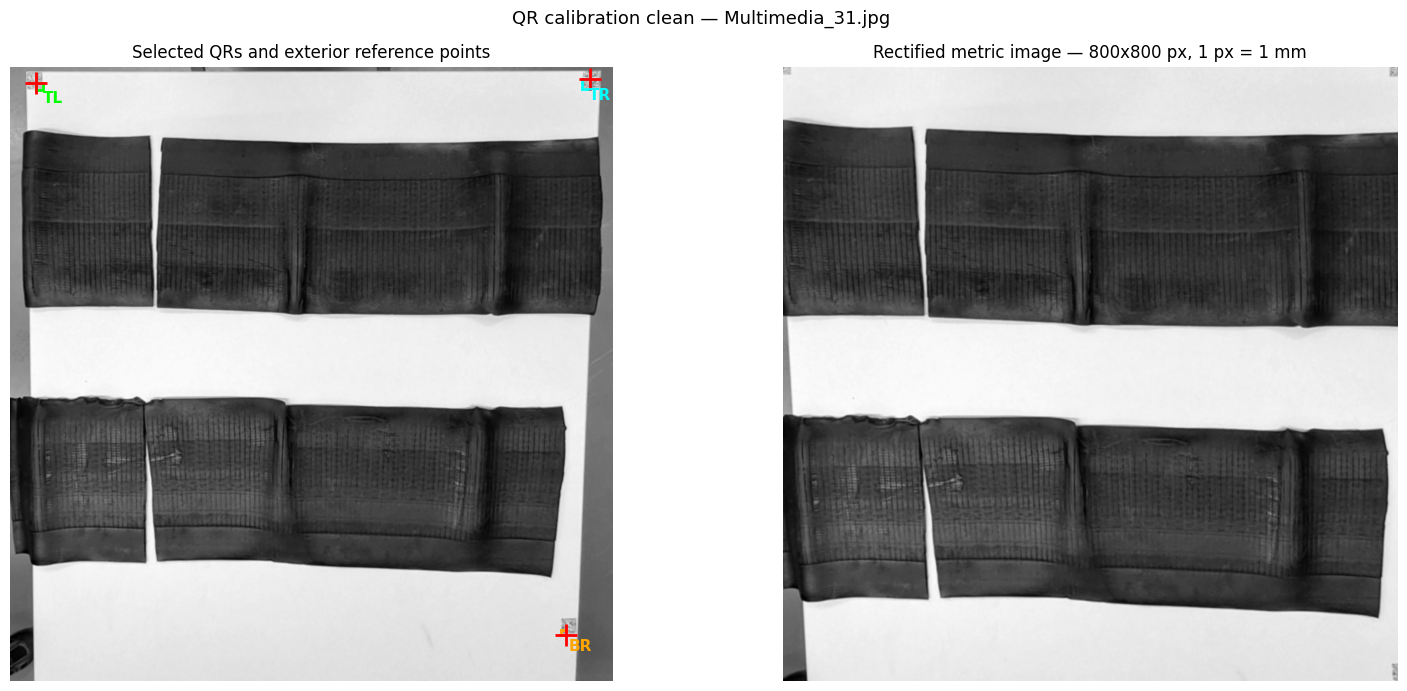

In [10]:
def visualize_result(image_name: str):
    calib = calibration_data[image_name]

    original = cv2.imread(str(PREPROCESSED_DIR / image_name), cv2.IMREAD_GRAYSCALE)
    rectified = cv2.imread(str(OUTPUT_DIR / image_name), cv2.IMREAD_GRAYSCALE)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f"QR calibration clean — {image_name}", fontsize=13)

    axes[0].imshow(original, cmap="gray")
    axes[0].set_title("Selected QRs and exterior reference points")

    colors = {
        "TL": "lime",
        "TR": "cyan",
        "BL": "magenta",
        "BR": "orange",
    }

    for label, bbox in calib["qr_labels"].items():
        x, y, w, h = bbox

        rect = plt.Rectangle(
            (x, y), w, h,
            linewidth=2,
            edgecolor=colors.get(label, "yellow"),
            facecolor="none"
        )

        axes[0].add_patch(rect)
        axes[0].annotate(
            label,
            (x, y),
            color=colors.get(label, "yellow"),
            fontsize=11,
            fontweight="bold",
            xytext=(5, -15),
            textcoords="offset points"
        )

    for cx, cy in calib["corners_px"]:
        axes[0].plot(cx, cy, "r+", markersize=16, markeredgewidth=2)

    axes[0].axis("off")

    axes[1].imshow(rectified, cmap="gray")
    axes[1].set_title("Rectified metric image — 800x800 px, 1 px = 1 mm")
    axes[1].axis("off")

    plt.tight_layout()
    plt.savefig(DEBUG_DIR / f"check_{Path(image_name).stem}.png", dpi=120)
    plt.show()


if calibration_data:
    visualize_result(next(iter(calibration_data)))
else:
    print("No images processed — inspect all_candidates debug outputs.")

## 9. Original scale distribution

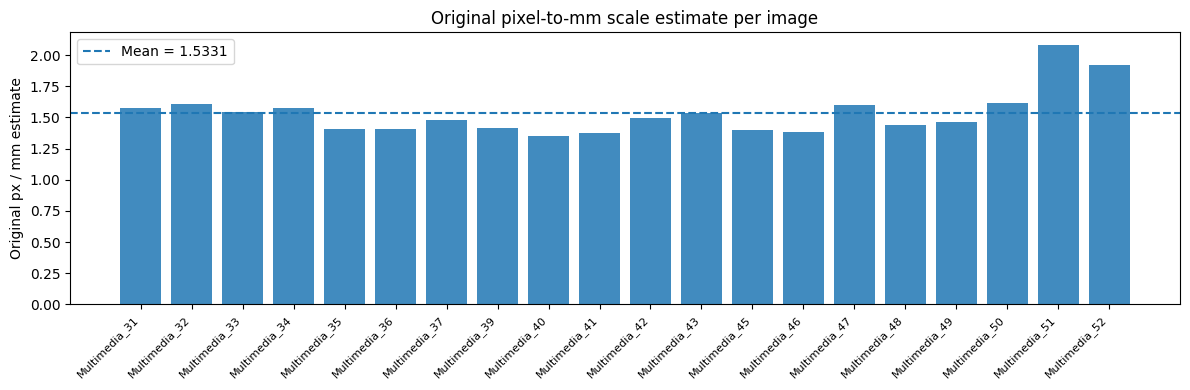

Mean  original px/mm : 1.5331
Std   original px/mm : 0.1770
Min   original px/mm : 1.3519  (Multimedia_40.jpg)
Max   original px/mm : 2.0778  (Multimedia_51.jpg)


In [11]:
if calibration_data:
    names = list(calibration_data.keys())
    scales = [calibration_data[n]["px_per_mm_original_estimate"] for n in names]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(range(len(names)), scales, alpha=0.85)
    ax.axhline(
        np.mean(scales),
        linestyle="--",
        label=f"Mean = {np.mean(scales):.4f}"
    )

    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(
        [Path(n).stem for n in names],
        rotation=45,
        ha="right",
        fontsize=8
    )

    ax.set_ylabel("Original px / mm estimate")
    ax.set_title("Original pixel-to-mm scale estimate per image")
    ax.legend()

    plt.tight_layout()
    plt.savefig(DEBUG_DIR / "scale_distribution_clean.png", dpi=150)
    plt.show()

    print(f"Mean  original px/mm : {np.mean(scales):.4f}")
    print(f"Std   original px/mm : {np.std(scales):.4f}")
    print(f"Min   original px/mm : {np.min(scales):.4f}  ({names[int(np.argmin(scales))]})")
    print(f"Max   original px/mm : {np.max(scales):.4f}  ({names[int(np.argmax(scales))]})")

## 10. Summary

This clean notebook follows a simpler logic than the previous version:

| Step | Operation | Detail |
|---|---|---|
| 1 | Read NB01 image | `gray_blur`, no CLAHE |
| 2 | Detect raw QR candidates | permissive visual detector |
| 3 | Assign candidates to corners | TL / TR / BL / BR |
| 4 | Select final QRs | best candidate per corner |
| 5 | Extract exterior reference points | according to selected corner |
| 6 | Compute affine transform | image pixels → metric square |
| 7 | Rectify image | 800x800 px, 1 px ≈ 1 mm |
| 8 | Save calibration | `calibration.json` |

Main design decision: the raw detector is allowed to produce false positives, but final selection only considers candidates close to image/table corners.